**Introduction**

This notebook implements and evaluates three CNN architectures: a baseline CNN, a Residual CNN, and a CNN with Batch Normalization. The objective is to analyse how architectural improvements affect training behaviour, convergence, and classification accuracy on the CIFAR-10 dataset.



**Imports - Key libraries**

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)


**Dataset Download and Pre-Processing**



In [29]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


**Baseline CNN Classifier - Code**

In [30]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(32*8*8,128)
        self.fc2 = nn.Linear(128,10)

        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1,32*8*8)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


**CNN Architecture and Layer Outputs**

- The input image is 32×32×3. The first convolution layer (3 - 16 filters) outputs 32×32×16, followed by max pooling to 16×16×16. The second convolution (16-32 filters) produces 16×16×32, followed by pooling to 8×8×32. The feature map is flattened into 2048 units and passed through a fully connected layer (128 units) before the final output layer of size 10. This structure captures basic spatial features such as edges and textures for classification.


**Training Function - Reusable**

In [31]:
def train_model(model, train_loader, test_loader, epochs=8):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # TEST PHASE
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:

                outputs = model(images)
                _, predicted = torch.max(outputs,1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)

        print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Accuracy={accuracy:.2f}%")

    return train_losses, test_accuracies


**Train Baseline CNN**

In [32]:
base_model = CNN()

base_loss, base_acc = train_model(
    base_model,
    train_loader,
    test_loader
)


Epoch 1: Loss=1.4414, Accuracy=54.56%
Epoch 2: Loss=1.1343, Accuracy=62.42%
Epoch 3: Loss=0.9881, Accuracy=65.22%
Epoch 4: Loss=0.8798, Accuracy=67.15%
Epoch 5: Loss=0.8014, Accuracy=68.61%
Epoch 6: Loss=0.7298, Accuracy=68.25%
Epoch 7: Loss=0.6702, Accuracy=69.66%
Epoch 8: Loss=0.6131, Accuracy=69.19%


**Baseline Model Graphs**

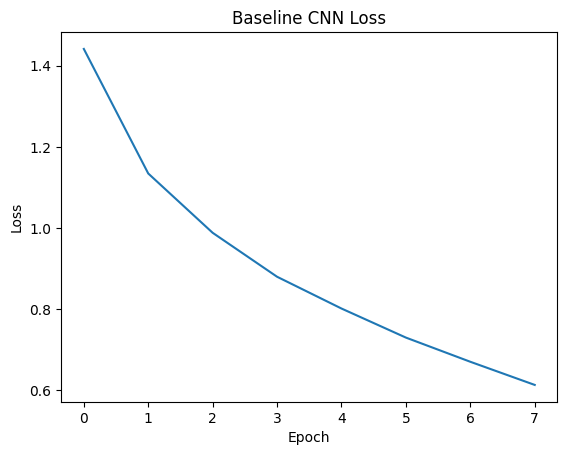

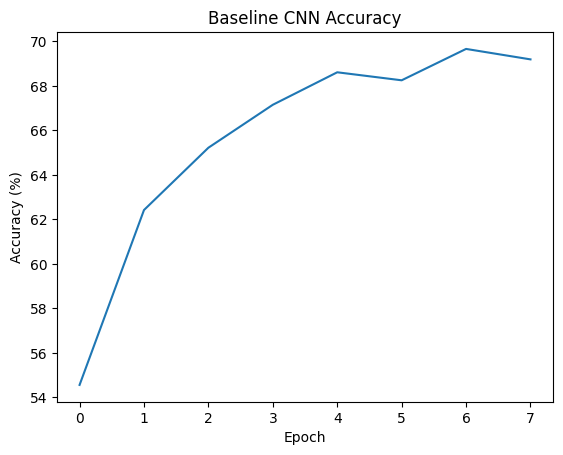

In [33]:
plt.plot(base_loss)
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(base_acc)
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()


**Loss Trajectory : Baseline CNN Model**

- Cross-Entropy Loss was used as CIFAR-10 is a multi-class classification problem. It measures the difference between predicted probabilities and true labels. The loss decreases steadily during training, indicating effective learning. The baseline CNN achieved a final loss of 0.6131, showing moderate optimisation but slower convergence compared to improved architectures.

**Accuracy Behaviour During Training : Baseline CNN**

- The baseline CNN achieved 69.19% accuracy, showing progressive learning across epochs. Accuracy increases initially as the model learns basic features, but begins to plateau due to limited depth. The gap between training and test performance indicates moderate generalisation, with some underfitting due to restricted feature representation capacity.



**Residual CNN Architecture**

In [34]:
class ResNetCNN(nn.Module):

    def __init__(self):

        super(ResNetCNN,self).__init__()

        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,16,3,padding=1)

        self.conv3 = nn.Conv2d(16,32,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(32*8*8,128)
        self.fc2 = nn.Linear(128,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        out = self.relu(self.conv1(x))

        residual = out

        out = self.conv2(out)
        out = self.relu(out + residual)

        out = self.pool(out)
        out = self.pool(self.relu(self.conv3(out)))

        out = out.view(-1,32*8*8)

        out = self.relu(self.fc1(out))
        out = self.fc2(out)

        return out


**Residual Structure Implementation**

- Residual connections were implemented by introducing skip connections that add the input of a layer to its output. This allows the network to learn residual mappings rather than full transformations, improving gradient flow and enabling more efficient learning in deeper architectures.


**Train Resnet Model**

In [35]:
res_model = ResNetCNN()

res_loss, res_acc = train_model(
    res_model,
    train_loader,
    test_loader
)


Epoch 1: Loss=1.4139, Accuracy=57.08%
Epoch 2: Loss=1.0581, Accuracy=65.50%
Epoch 3: Loss=0.8985, Accuracy=68.76%
Epoch 4: Loss=0.7872, Accuracy=70.17%
Epoch 5: Loss=0.7002, Accuracy=70.84%
Epoch 6: Loss=0.6221, Accuracy=71.48%
Epoch 7: Loss=0.5544, Accuracy=71.26%
Epoch 8: Loss=0.4890, Accuracy=70.61%


**Comparison Plots : ResNet Vs Baseline Model**

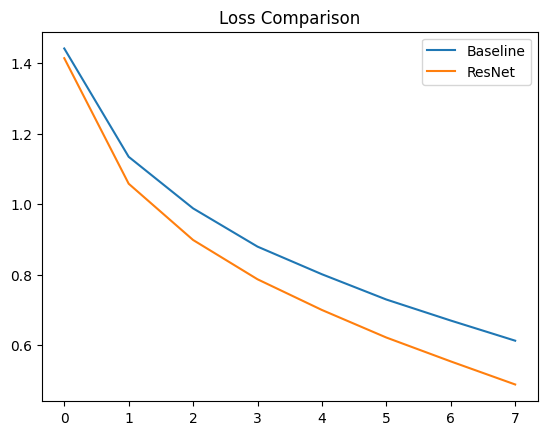

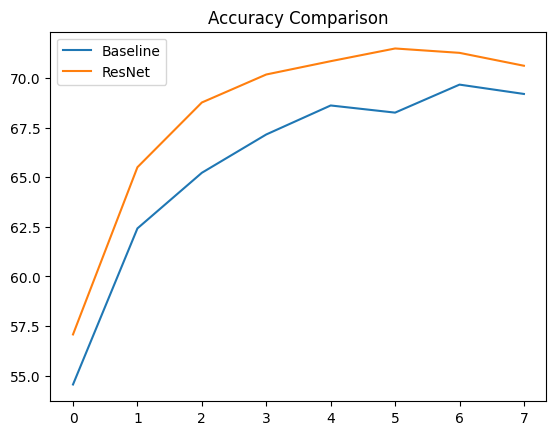

In [36]:
plt.plot(base_loss, label="Baseline")
plt.plot(res_loss, label="ResNet")
plt.title("Loss Comparison")
plt.legend()
plt.show()

plt.plot(base_acc, label="Baseline")
plt.plot(res_acc, label="ResNet")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()


**Baseline CNN vs Residual CNN**

- The residual CNN achieved lower loss (0.4890) and higher accuracy (70.61%) compared to the baseline (loss 0.6131, accuracy 69.19%). Loss curves show faster and smoother convergence, while accuracy improves slightly. This indicates better optimisation and more stable training behaviour due to improved gradient propagation.


**Batchnorm CNN Architecture**

In [37]:
class BatchNormCNN(nn.Module):

    def __init__(self):

        super(BatchNormCNN,self).__init__()

        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(32*8*8,128)
        self.fc2 = nn.Linear(128,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.view(-1,32*8*8)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


**Batch Normalization Implementation**

- Batch Normalization was applied after convolution layers to normalize feature maps within each batch. This reduces internal covariate shift and stabilizes training. It ensures consistent feature distributions, allowing the model to converge more efficiently.


**Train Batchnorm CNN Classifier**

In [38]:
bn_model = BatchNormCNN()

bn_loss, bn_acc = train_model(
    bn_model,
    train_loader,
    test_loader
)


Epoch 1: Loss=1.2664, Accuracy=61.69%
Epoch 2: Loss=0.9717, Accuracy=66.54%
Epoch 3: Loss=0.8554, Accuracy=67.27%
Epoch 4: Loss=0.7892, Accuracy=69.11%
Epoch 5: Loss=0.7280, Accuracy=69.20%
Epoch 6: Loss=0.6705, Accuracy=71.56%
Epoch 7: Loss=0.6285, Accuracy=71.06%
Epoch 8: Loss=0.5879, Accuracy=70.30%


**Graph : BatchNorm Vs Baseline Model**

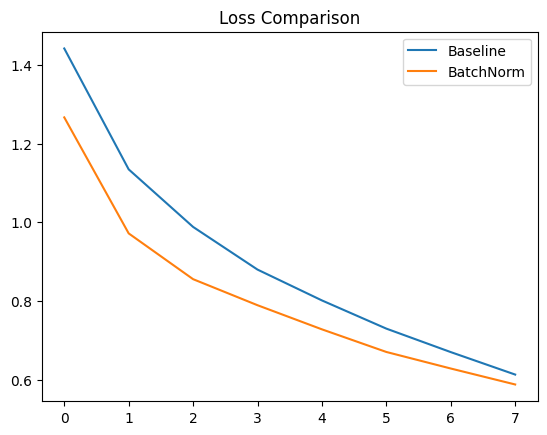

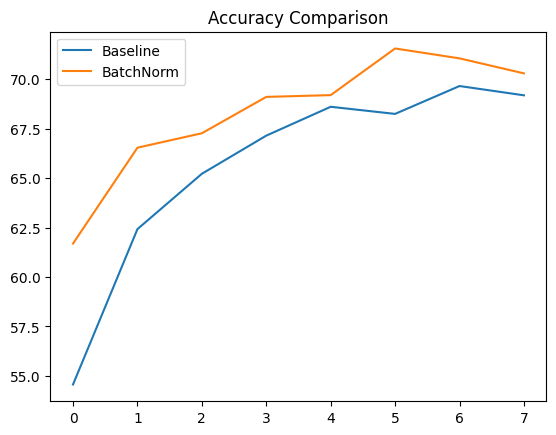

In [40]:
plt.plot(base_loss, label="Baseline")
plt.plot(bn_loss, label="BatchNorm")
plt.title("Loss Comparison")
plt.legend()
plt.show()

plt.plot(base_acc, label="Baseline")
plt.plot(bn_acc, label="BatchNorm")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()


**Baseline CNN vs BatchNorm CNN**

- The BatchNorm CNN achieved a loss of 0.5879 and accuracy of 70.30%, improving over the baseline (loss 0.6131, accuracy 69.19%). Loss curves show slightly smoother convergence, while accuracy improves marginally. Compared to the residual model, the impact is smaller but still positive.


**Conclusion**

- The baseline CNN achieved 69.19% accuracy, while the residual CNN reached 70.61% and the BatchNorm CNN achieved 70.30%. The residual model performed best, showing the lowest loss and improved optimisation. Batch Normalization provided moderate improvements in stability and accuracy. Overall, architectural enhancements improved training behaviour and generalisation, with residual connections having the greatest impact.
